# Shaffer Chapter 7

## 7.1

> Using weak induction, prove that the Insertion Sort algorithm, as presented in class, will produce a sorted list of data elements.

---

### Insertion Sort Algorithm as Presented in Class

Idea: Build a sorted list an item at a time by inserting the next item into the growing list in the correct position.

### Proof by Weak Induction on the Length of the List

Let $L = [L_1, L_2, \ldots, L_n]$ be a sequence (list) of elements inserted from some set $A$, and let $R \subseteq A \times A$ be a binary relation on $A$.

We define sortedness of $L$ with respect to $R$ as follows:

$$
\forall i, j \in \mathbb{N}, \; i < j \rightarrow R(L_i, L_j)
$$

**Base Case**:

For $n = 1$, the list $L$ has only one element, and it is trivially sorted. Similarly, for $n = 0$, the list is empty, and the property vacuously holds.

**Inductive Hypothesis**:

Assume that for some $n = k$, the list $L$ with $k$ elements, sorted by the Insertion Sort algorithm, satisfies the sortedness property with respect to $R$.

**Inductive Step**:

Consider the list $L$ with $n = k + 1$ elements. The Insertion Sort algorithm inserts the $(k + 1)$-th element into the sorted list of $k$ elements.

Let this new element be $a$.

The algorithm determines the correct position for $a$ by starting from the beginning (or end) of the list and finding the first index $i$ such that $R(a, L_i)$ (or $R(L_i, a)$ if starting from the end). The algorithm then inserts $a$ at index $i$.

Since the algorithm ensures that $\forall m < i, \; R(L_m, a)$, the list remains sorted up to index $i$ after insertion. 

For elements at indices after $i$, we have a contiguous subsequence $L[i:]$. Since $L$ was already sorted by the inductive hypothesis, this subsequence $L[i:]$ retains sortedness by the transitivity of $R$.

Finally, since $R(a, L_i)$ holds and $\forall m > i, \; R(L_i, L_m)$ (by transitivity of $R$), it follows that $\forall m \geq i, \; R(a, L_m)$.

Therefore, the list $L$ with $n = k + 1$ elements is sorted. By weak induction, the Insertion Sort algorithm produces a sorted list of data elements. $\blacksquare$

## 7.2

> Write an Insertion Sort algorithm for integer key values. However, here’s
> the catch: The input is a stack (not an array), and the only variables that
> your algorithm may use are a fixed number of integers and a fixed number of
> stacks. The algorithm should return a stack containing the records in sorted
> order (with the least value being at the top of the stack). Your algorithm
> should be Θ(n2 ) in the worst case.

---


In [90]:
from collections import deque

def insertion_sort_stacks(arr):
  if len(arr) < 2: return arr

  sorted_stack, buffer_stack = deque(), deque()
  sorted_stack.append(arr[0])

  for i in range(1, len(arr)):
    new_el = arr[i]
    top = sorted_stack.pop()
    
    while top > new_el and sorted_stack:
      buffer_stack.append(top)
      top = sorted_stack.pop()

    if top < new_el:
      sorted_stack.append(top)
      sorted_stack.append(new_el)
    else:
      sorted_stack.append(new_el)
      sorted_stack.append(top)

    while buffer_stack:
      sorted_stack.append(buffer_stack.pop())

  return list(sorted_stack)


sample_array = [1,5,9,2,7]

sorted_ = insertion_sort_stacks(sample_array)
sorted_


[1, 2, 5, 7, 9]

## 7.3

> The Bubble Sort implementation has the following inner for loop:

```java
for (int j=n-1; j>i; j--)
```

> Consider the effect of replacing this with the following statement:

```java
for (int j=n-1; j>0; j--)
```

> Would the new implementation work correctly? Would the change affect the
> asymptotic complexity of the algorithm? How would the change affect the
> running time of the algorithm?

----

In [91]:
def bubble_sort_normal(arr):
  for i in range(len(arr)):
    for j in range (len(arr) - 1, i + 1, -1):
      if arr[j] < arr[j - 1]:
        arr[j], arr[j - 1] = arr[j - 1], arr[j]
  return arr

def bubble_sort_no_reduction(arr):
  for _ in range(len(arr)):
    for j in range (len(arr) - 1, 0, -1):
      if arr[j] < arr[j - 1]:
        arr[j], arr[j - 1] = arr[j - 1], arr[j]
  return arr

sample_array = [1,5,9,2,7,12,10,16,14,11,13,4,15]
sorted_ = bubble_sort_normal(sample_array)
sorted_2 = bubble_sort_no_reduction(sample_array)
sorted_, sorted_2


([1, 2, 4, 5, 7, 9, 10, 11, 12, 13, 14, 15, 16],
 [1, 2, 4, 5, 7, 9, 10, 11, 12, 13, 14, 15, 16])

In [92]:
# Measure difference in time
import time
import random

sample_array = [random.randint(0, 4000) for _ in range(3000)]

start = time.time()
sorted_2 = bubble_sort_no_reduction(sample_array)
end = time.time()

print(f"Time taken for bubble_sort_no_reduction: {end - start}")

sample_array = [random.randint(0, 4000) for _ in range(3000)]

start = time.time()
sorted_ = bubble_sort_normal(sample_array)
end = time.time()

print(f"Time taken for bubble_sort_normal: {end - start}")

Time taken for bubble_sort_no_reduction: 0.5307698249816895
Time taken for bubble_sort_normal: 0.3310360908508301


The running time expectedly gets worse when you don't reduce the range of the inner loop on each iterattion of the outer loop.

The asymptotic complexity of the algorithm is still the same $(O(n^2))$. but the constant factor is larger.

### Shaker Sort

In [ ]:
arr = [1,2,3,4]
n = len(arr)

swapped = True
start = 0
end = n - 1

while swapped:
    swapped = False
    # Left to Right
    for i in range(start, end):
        if arr[i] > arr[i + 1]:
            arr[i], arr[i + 1] = arr[i + 1], arr[i]
            swapped = True

    end -= 1

    # Right to Left
    for i in range(end, start, -1):
        if arr[i] < arr[i - 1]:
            arr[i], arr[i - 1] = arr[i - 1], arr[i]
            swapped = True

    start += 1

## 7.4


> When implementing Insertion Sort, a binary search could be used to locate
> the position within the first i − 1 elements of the array into which element
> i should be inserted. How would this affect the number of comparisons re-
> quired? How would using such a binary search affect the asymptotic running
> time for Insertion Sort?

----

The number of comparisons required would be reduced to $O(\log n)$, but the number of swaps would still be $O(n^2)$, so the overall complexity would still be $O(n^2)$.




## 7.5

> Figure 7.5 shows the best-case number of swaps for Selection Sort as Θ(n).
> This is because the algorithm does not check to see if the ith record is already
> in the ith position; that is, it might perform unnecessary swaps.

### (a) 

> Modify the algorithm so that it does not make unnecessary swaps.

----

In [93]:
def selection_sort(arr):
  for i in range(len(arr)):
    min_index = i

    for j in range(i, len(arr)):
      if arr[j] < arr[min_index]:
        min_index = j

    arr[i], arr[min_index] = arr[min_index], arr[i]

  return arr

def selection_sort_improved_best_case(arr):
  for i in range(len(arr)):
    min_index = i
    need_swap = False # Add flag 
    
    for j in range(i, len(arr)):
      if arr[j] < arr[min_index]:
        need_swap = True
        min_index = j

    if need_swap:
      arr[i], arr[min_index] = arr[min_index], arr[i]

  return arr

sample_array = [1,5,9,2,7,12,10,16,14,11,13,4,15]
sorted_ = selection_sort(sample_array)
sorted_2 = selection_sort_improved_best_case(sample_array)
sorted_, sorted_2

([1, 2, 4, 5, 7, 9, 10, 11, 12, 13, 14, 15, 16],
 [1, 2, 4, 5, 7, 9, 10, 11, 12, 13, 14, 15, 16])

#### (b) 

> What is your prediction regarding whether this modification actually improves the running time?

---

We are essentially trading a swap for some comparisons (depending on implementation). 


Since selection sort is already bottlenecked by the number of comparisons, this change would not change the complexity of the algorithm.


In the best case, the number of swaps is reduced to 0 though.


If the flag/branch is more efficient than the average number of unnecessary swaps, then the running time would be improved.


#### (c)

> Write two programs to compare the actual running times of the origi-
> nal Selection Sort and the modified algorithm. Which one is actually
> faster?

---

In [94]:
sample_array = [random.randint(0, 4000) for _ in range(3000)]

start = time.time()
sorted_ = selection_sort(sample_array)
end = time.time()

print(f"Time taken for selection_sort: {end - start}")

sample_array = [random.randint(0, 4000) for _ in range(3000)]

start = time.time()
sorted_2 = selection_sort_improved_best_case(sample_array)
end = time.time()

print(f"Time taken for selection_sort_improved_best_case: {end - start}")

Time taken for selection_sort: 0.13283562660217285
Time taken for selection_sort_improved_best_case: 0.13297462463378906


Evidently, the modified algorithm seems faster.


## 7.6

> Recall that a sorting algorithm is said to be stable if the original ordering for duplicate keys is preserved. Of the sorting algorithms Insertion Sort, Bubble Sort, Selection Sort, Shellsort, Mergesort, Quicksort, Counting Sort, and Radix Sort, which of these are stable, and which are not? 
> 
> For each one, describe either why it is or is not stable. If a minor change to the implementation would make it stable, describe the change
>
> (drop Heapsort and BinSort, add Counting Sort)


---

### Insertion Sort

**Stability**: Insertion Sort is stable.

**Explanation**: Insertion Sort iterates through the list, inserting each element into its correct position within the sorted portion of the list. If there are duplicate elements, the insertion process places each new occurrence after previous occurrences, preserving their relative order. This stability arises from the fact that insertion is performed by moving elements one position at a time rather than swapping, ensuring duplicates retain their input order.

### Bubble Sort

**Stability**: Bubble Sort is stable.

**Explanation**: Bubble Sort repeatedly swaps adjacent elements if they are out of order. Since it only swaps elements when the left element is greater than the right element, it leaves duplicates in their original relative order. Thus, when two duplicate elements are adjacent, they will not be swapped, preserving stability.

### Selection Sort

**Stability**: Selection Sort is not stable.

**Explanation**: Selection Sort finds the minimum element in the unsorted portion and swaps it with the first unsorted element. This swap operation can disrupt the relative order of duplicate elements if a duplicate minimum value is swapped with an earlier position in the list. For example, if two equal elements are found at different positions, the later occurrence may be moved ahead of the earlier occurrence.

**Modification for Stability**: To make Selection Sort stable, instead of swapping, we could move the minimum element to its correct position by shifting all elements between the minimum's original position and the insertion point to the right. This approach ensures that duplicate elements remain in their initial order.

### Shellsort

**Stability**: Shellsort is generally not stable.

**Explanation**: Shellsort sorts elements at varying gap distances, which can result in non-adjacent elements being swapped. When duplicates are involved, this can disrupt their relative order since elements are moved long distances based on the gap sequence. Stability is not inherently guaranteed due to these non-local swaps.

**Modification for Stability**: To make Shellsort stable, one could restrict the gap sequence and swaps to only affect elements within their original sublist ordering. However, this modification undermines Shellsort’s efficiency and is generally impractical.

### Mergesort

**Stability**: Mergesort is stable.

**Explanation**: Mergesort recursively divides the list into halves, sorts each half, and then merges them. During the merge step, if two elements are equal, Mergesort consistently places the element from the left half before the element from the right half. This consistent choice preserves the initial order of duplicates across the merge operations, ensuring stability.

### Quicksort

**Stability**: Quicksort is not stable.

**Explanation**: Quicksort partitions the list around a pivot element and recursively sorts each partition. During partitioning, elements equal to the pivot can end up in different relative positions depending on the specific partitioning implementation (such as Lomuto or Hoare partition schemes). These placements disrupt the relative order of duplicates, resulting in an unstable sort.

**Modification for Stability**: To make Quicksort stable, one can use a three-way partitioning scheme that separates elements into three groups: those less than, equal to, and greater than the pivot. Elements equal to the pivot retain their input order, preserving stability. However, this adjustment can impact Quicksort's typical performance characteristics.

### Counting Sort

**Stability**: Counting Sort is stable.

**Explanation**: Counting Sort counts occurrences of each element and uses these counts to position elements directly in the output array. When duplicates are present, elements are placed in the output in the same order as they appear in the input, since the counts are processed sequentially. This order-preserving placement ensures stability.

### Radix Sort

**Stability**: Radix Sort is stable.

**Explanation**: Radix Sort sorts elements digit by digit, starting with the least significant digit. For each digit level, it applies a stable sorting algorithm (such as Counting Sort) to sort the elements based on that digit. Because each pass preserves the relative order of elements with equal digit values, Radix Sort maintains the original order of duplicates throughout the sorting process, ensuring stability.

## 7.7

> Recall that a sorting algorithm is said to be stable if the original ordering for
> duplicate keys is preserved. We can make any algorithm stable if we alter
> the input keys so that (potentially) duplicate key values are made unique in
> a way that the first occurrence of the original duplicate value is less than the
> second occurrence, which in turn is less than the third, and so on. In the worst
> case, it is possible that all n input records have the same key value. Give an
> algorithm to modify the key values such that every modified key value is
> unique, the resulting key values give the same sort order as the original keys,
> the result is stable (in that the duplicate original key values remain in their
> original order), and the process of altering the keys is done in linear time
> using only a constant amount of additional space.

---

In [95]:
def remap_keys(arr):
  n = len(arr)
  fractional_scale = 1.0 / n
  for i in range(n):
    increment = i * fractional_scale # Since increment must be < 1, it only affects ordering of duplicates
    arr[i] = arr[i] + increment
  return arr

example_arr = [3, 2, 2, 1]
selection_sort(remap_keys(example_arr))
example_arr

[1.75, 2.25, 2.5, 3.0]

## 7.8

> The discussion of Quicksort in Section 7.5 described using a stack instead of
> recursion to reduce the number of function calls made.


### (a) 

> How deep can the stack get in the worst case?

----

In [96]:
def partition_always_left(A, low, high):
    pivot = A[low]  # Use the leftmost element as the pivot
    i = low + 1
    j = high
    
    while True:
        # Move i to the right as long as elements are <= pivot
        while i <= j and A[i] <= pivot:
            i += 1
        # Move j to the left as long as elements are > pivot
        while i <= j and A[j] > pivot:
            j -= 1
        if i <= j:
            # Swap elements at i and j
            A[i], A[j] = A[j], A[i]
        else:
            break

    # Place the pivot in its correct position
    A[low], A[j] = A[j], A[low]
    return j  # Return the final pivot position

def quicksort_with_stack(A, call_order="push empty first"):
    max_stack_depth = 0
    stack = [(0, len(A) - 1)]  # Initialize stack with the bounds of the whole array
    
    while stack:
        if len(stack) > max_stack_depth:
            max_stack_depth = len(stack)

        low, high = stack.pop()

        if low < high:
            pivot = partition_always_left(A, low, high)

            if call_order == "push empty first":
              stack.append((low, pivot - 1))
              stack.append((pivot + 1, high))
            else:
              stack.append((pivot + 1, high))  # Push right partition
              stack.append((low, pivot - 1))  # Push left partition

    print(f"Max stack depth for array of length {len(A)}: {max_stack_depth}")
    return A

worst_case_arr = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
quicksort_with_stack(worst_case_arr)


Max stack depth for array of length 10: 10


[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]



### (b) 

> Quicksort makes two recursive calls. The algorithm could be changed
> to make these two calls in a specific order. In what order should the
> two calls be made, and how does this affect how deep the stack can
> become?

---

In [97]:
print("When empty partition gets pushed first in each iteration")
quicksort_with_stack(worst_case_arr, call_order="push empty first")

print("\nWhen non-empty partition gets pushed first in each iteration")
quicksort_with_stack(worst_case_arr, call_order="push non-empty first")

When empty partition gets pushed first in each iteration
Max stack depth for array of length 10: 10

When non-empty partition gets pushed first in each iteration
Max stack depth for array of length 10: 2


[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

In the worst-case for quicksort, each partition creates one empty partition and one partition with $n-1$ elements.

If, during each iteration, the non-empty partition is pushed onto the stack first (followed by the empty partition), the stack will have $2$ elements with bounds `n, n` on the top (since an empty partition is represented by matching left and right bounds).

During the proceeding iteration, the empty partition gets popped first (since it's on top). Since it's empty (meets condition `low >= high` or `left >= right`), the base case is met and there is no recursion or stack push. We then pop the non-empty partition, leaving the stack empty and starting this process over again. 

Thus, the maximum stack depth is $2$ in the worst-case when the non-empty partition is always pushed first. 

## 7.9

> Give a permutation for the values 0 through 7 that will cause Quicksort (as
> implemented in Section 7.5) to have its worst case behavior.

----

#### Visualize Quicksort Partitioning Algorithm

In [98]:
def visualize_quicksort_partition(arr, low, high):
    pivot = arr[high]
    i = low - 1
    print(f"Pivot: {pivot} | Low: {low} | High: {high}")
    print(arr)
    for j in range(low, high):
        if arr[j] < pivot:
            i += 1
            print(f"\ni = {i}, j = {j}", end=" | ")
            arr[i], arr[j] = arr[j], arr[i]
            print(f"Swapped {arr[i]} with {arr[j]}\nArray: {arr}")
    arr[i + 1], arr[high] = arr[high], arr[i + 1]
    return i + 1

test_arr = [10, 80, 30, 90, 40, 50, 70]
x = visualize_quicksort_partition(test_arr, 0, 6)
x, test_arr

Pivot: 70 | Low: 0 | High: 6
[10, 80, 30, 90, 40, 50, 70]

i = 0, j = 0 | Swapped 10 with 10
Array: [10, 80, 30, 90, 40, 50, 70]

i = 1, j = 2 | Swapped 30 with 80
Array: [10, 30, 80, 90, 40, 50, 70]

i = 2, j = 4 | Swapped 40 with 80
Array: [10, 30, 40, 90, 80, 50, 70]

i = 3, j = 5 | Swapped 50 with 90
Array: [10, 30, 40, 50, 80, 90, 70]


(4, [10, 30, 40, 50, 70, 90, 80])

To ensure the worst case, we want to arrange the number such that the pivot is always picking the smallest or largest element.

In the implementation wherein the pivot is always the midpoint, we clearly want the largest number in the middle slot to start with:

```python
[_, _, _, _, 7, _, _, _] # len(arr) = 8, 8 // 2 = 4. place at index 4
```

The `partition` function will either:

1. move the pivot to the end, and then swap the end with the returned `high` index from the recursive call (if it's the highest value, the `high` index will be the end of the index anyway, so the swap will be a no-op), or
2. during iterative swaps, keep moving the pivot to the end of the array until it's the highest value.

In either case, the pivot (if it's the max value) gets moved to the end, and the returned value by the `partition` function is the end of the array.

The two recursive calls like:

```python
quicksort(arr, k + 1, high) # right partition, but high + 1 == high, so it's empty, and skipped
quicksort(arr, low, k - 1) # only left partition gets recursed on
```

Now we need to place the second highest value in the middle of the left partition `arr[low:k - 1]`:

```python
[_, _, _, 6, _, _, _] # len(arr) = 7, 7 // 2 = 3. place at index 3
```

Then `6` gets moved to the end and we keep repeating

```python
[_, _, _, 5, _, _] # len(arr) = 6, 6 // 2 = 3. place at index 3
```


```python
[_, _, 4, _, _] # len(arr) = 5, 5 // 2 = 2. place at index 2
```

And we keep alternating back and forth. So the original list should be:

```python
[0, 2, 4, 6, 7, 5, 3, 1]
```


Verify using the stack-based quicksort implementation:

In [134]:
def partition(arr, low, high):
    pivot = arr[(low + high 
                 ) // 2]  # Select middle element as pivot
    pivot_index = (low + high) // 2
    print(f"\nPivot: {pivot} | Low: {low} | High: {high}")
    arr[pivot_index], arr[high] = arr[high], arr[pivot_index]  # Move pivot to the end
    print(f"Array after moving pivot to the end: {arr}")
    i = low - 1
    for j in range(low, high):
        if arr[j] < pivot:
            i += 1
            arr[i], arr[j] = arr[j], arr[i]
    arr[i + 1], arr[high] = arr[high], arr[i + 1]  # Place pivot correctly
    return i + 1

def quicksort_with_stack(A):
    max_stack_depth = 0
    stack = [(0, len(A) - 1)]  # Initialize stack with the bounds of the whole array

    while stack:
        if len(stack) > max_stack_depth:
            max_stack_depth = len(stack)

        low, high = stack.pop()

        if low < high:
            # Always select the middle element as the pivot
            pivot = partition(A, low, high)

            print(f"\nRight partition: {A[pivot + 1:high + 1]}")
            print(f"Left partition: {A[low:pivot]}")

            # Push left and right partitions to stack
            stack.append((low, pivot - 1))  # Left partition
            stack.append((pivot + 1, high))  # Right partition

    print(f"Max stack depth for array of length {len(A)}: {max_stack_depth}")
    return A

worst_case_arr_permutation = [0, 2, 4, 6, 7, 5, 3, 1]
sorted_array = quicksort_with_stack(worst_case_arr_permutation)
print("\nSorted Array:", sorted_array)



Pivot: 6 | Low: 0 | High: 7
Array after moving pivot to the end: [0, 2, 4, 1, 7, 5, 3, 6]

Right partition: [7]
Left partition: [0, 2, 4, 1, 5, 3]

Pivot: 4 | Low: 0 | High: 5
Array after moving pivot to the end: [0, 2, 3, 1, 5, 4, 6, 7]

Right partition: [5]
Left partition: [0, 2, 3, 1]

Pivot: 2 | Low: 0 | High: 3
Array after moving pivot to the end: [0, 1, 3, 2, 4, 5, 6, 7]

Right partition: [3]
Left partition: [0, 1]

Pivot: 0 | Low: 0 | High: 1
Array after moving pivot to the end: [1, 0, 2, 3, 4, 5, 6, 7]

Right partition: [1]
Left partition: []
Max stack depth for array of length 8: 2

Sorted Array: [0, 1, 2, 3, 4, 5, 6, 7]


## 7.10

> Assume `L` is an array, `L.length()` returns the number of records in the
> array, and `qsort(L, i, j)` sorts the records of `L` from `i` to `j` (leaving
> the records sorted in `L`) using the Quicksort algorithm. What is the average-
> case time complexity for each of the following code fragments?




### (a) 

```java
for (i=0; i<L.length; i++)
  qsort(L, 0, i);
```

----

We have:

- $i = 0 \mapsto O(1)$
- $i = 1 \mapsto O(1)$
- $i = 2 \mapsto O(n \log n) = O(2 \log 2)$
- $i = 3 \mapsto O(n \log n) = O(3 \log 3)$
- $\ldots$
- $i = n \mapsto O(n \log n) = O(n \log n)$

Thus:

$$
T(n) = O(1) + O(1) + O(2 \log 2) + O(3 \log 3) + \ldots + O(n \log n)
$$

In general form:

- $0 + $
- $(n - 1) \log (n - 1) + $
- $(n - 2) \log (n - 2) + $
- $\ldots + $
- $1 \log 1$

Since $\forall x > 1, c < x, \; \log x > \log (x - c)$, we can say that the upper bound is:

- $0 + $
- $(n - 1) \log n + $
- $(n - 2) \log n + $
- $\ldots + $
- $1 \log 1$

The sum of terms from $0$ to $n$ is:

$$
\frac{n(n + 1)}{2}
$$

Since $\forall x > 1, \log x > 1$, we can say that the upper bound is:

$$
\frac{n(n + 1)}{2} \log n
$$

Simplify:

$$
\frac{n(n + 1)}{2} \log n = \frac{n^2 + n}{2} \log n \implies
$$

$$
O \in O(n^2 \log n)
$$



### (b) 

```java
for (i=0; i<L.length; i++)
  qsort(L, 0, L.length-1);
```

----



For each iteration, we are performing `quicksort` on the entire array with time complexity $O(n \log n)$.

The loop iterates $n$ times, so the total time complexity is $O(n^2 \log n)$.

## 7.11

> Modify Quicksort to find the smallest k values in an array of records. Your
> output should be the array modified so that the k smallest values are sorted
> in the first k positions of the array. Your algorithm should do the minimum
> amount of work necessary, that is, no more of the array than necessary should
> be sorted.

----

In [208]:
from typing import List, TypeVar

T = TypeVar('T')

def find_k_smallest(arr: List[T], k: int) -> None:
    """
    Modifies the array in-place so that the k smallest elements are in the first
    k positions, sorted in ascending order. The rest of the array is left unsorted.
    """
    if k <= 0 or k > len(arr):
        return

    # Helper function to partition the array
    def partition(left: int, right: int, pivot_index: int) -> int:
        pivot_value = arr[pivot_index]
        # Move pivot to the end
        arr[pivot_index], arr[right] = arr[right], arr[pivot_index]
        store_index = left
        for i in range(left, right):
            if arr[i] < pivot_value:
                arr[i], arr[store_index] = arr[store_index], arr[i]
                store_index += 1
        # Move pivot to its final place
        arr[store_index], arr[right] = arr[right], arr[store_index]
        return store_index

    # Quickselect to find the first k smallest elements
    def quickselect(left: int, right: int, k: int) -> None:
        if left < right:
            pivot_index = (left + right) // 2  # Choose the middle element as the pivot
            new_pivot = partition(left, right, pivot_index)
            if new_pivot == k:
                return
            elif new_pivot < k:
                quickselect(new_pivot + 1, right, k)
            else:
                quickselect(left, new_pivot - 1, k)

    # Step 1: Use quickselect to find the first k smallest elements
    quickselect(0, len(arr) - 1, k)

    # Step 2: Sort the first k elements
    arr[:k] = sorted(arr[:k])


example_arr = [10, 3, 16, 4, 8, 0, 4, 2, 7, 1, 5, 17, 22, 31, 6, 9]
find_k_smallest(example_arr, 3)
example_arr

[0, 1, 2, 3, 8, 10, 4, 9, 7, 16, 5, 17, 22, 31, 6, 4]

## 7.12

> Modify Quicksort to sort a sequence of variable-length strings stored one
> after the other in a character array, with a second array (storing pointers to
> strings) used to index the strings. Your function should modify the index
> array so that the first pointer points to the beginning of the lowest valued
> string, and so on.


---

## 7.13

> Graph $f_1(n) = n \log n, f_2(n) = n^{1.5}$, and $f_3(n) = n^2$ in the range $1 ≤ n ≤ 1000$ 
> to visually compare their growth rates. Typically, the constant factor
> in the running-time expression for an implementation of Insertion Sort will
> be less than the constant factors for Shellsort or Quicksort. How many times
> greater can the constant factor be for Shellsort to be faster than Insertion Sort
> when $n = 1000$? How many times greater can the constant factor be for
> Quicksort to be faster than Insertion Sort when $n = 1000$?


---

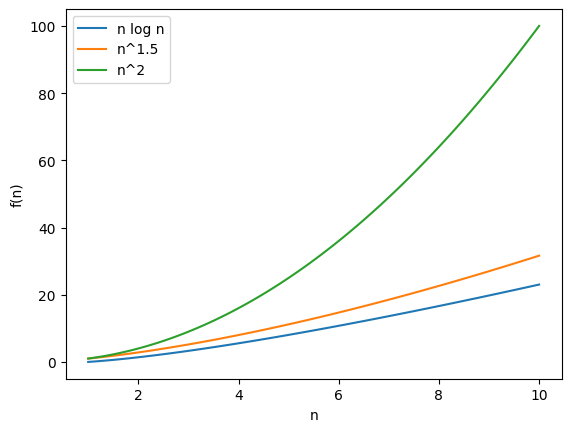

In [209]:
import matplotlib.pyplot as plt
import numpy as np

# graph f1(n) = nlogn, f2(n) = n^(1.5), f3(n) = n^2
n = np.linspace(1, 10, 100)
f1 = n * np.log(n)
f2 = n ** 1.5
f3 = n ** 2

plt.plot(n, f1, label="n log n")
plt.plot(n, f2, label="n^1.5")
plt.plot(n, f3, label="n^2")
plt.xlabel("n")
plt.ylabel("f(n)")
plt.legend()
plt.show()

- Insertion Sort $\in O(n^2)$
- Shellsort $\in O(n ^{1.5})$
- Quicksort $\in O(n \log n)$

Let $a$ be a constant factor for Shellsort such that Shellsort $\in O(a n^{1.5})$.

In order for Shellsort to be faster than Insertion Sort when $n = 1000$, we need:

$$
a \cdot 1000^{1.5} < 1000^2 \implies a < 1000^{0.5} = 31.62
$$

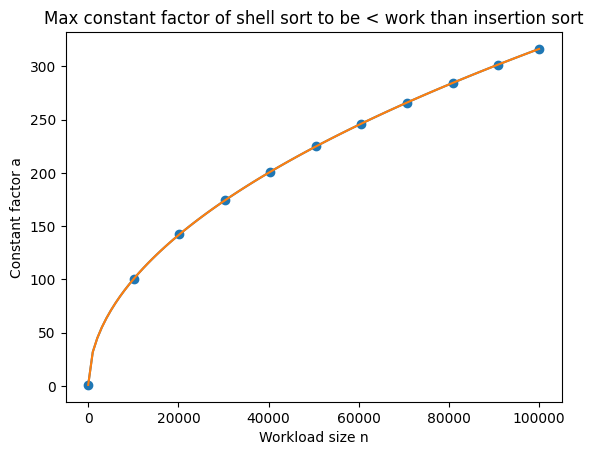

In [226]:
# Plot relationship between constant factor a and n
a = np.linspace(1, 10, 100)
n = np.linspace(1, 100000, 100)
a = (n ** .5)
# Add markers to visualize various points along the curve
plt.plot(n, a, marker='o', markevery=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 99])
plt.plot(n, a)
plt.xlabel("Workload size n")
plt.ylabel("Constant factor a")
plt.title("Max constant factor of shell sort to be < work than insertion sort")
plt.show()

Let $b$ be a constant factor for Quicksort such that Quicksort $\in O(b n \log n)$.

In order for Quicksort to be faster than Insertion Sort when $n = 1000$, we need:

$$
b \cdot 1000 \log 1000 < 1000^2 \implies b < \frac{1000}{\log 1000} = 1000 / 3.0 = 333.33
$$

Thus, the constant factor for Shellsort can be at most $31.62$ times greater, and for Quicksort, it can be at most $333.33$ times greater for them to be faster than Insertion Sort when $n = 1000$.

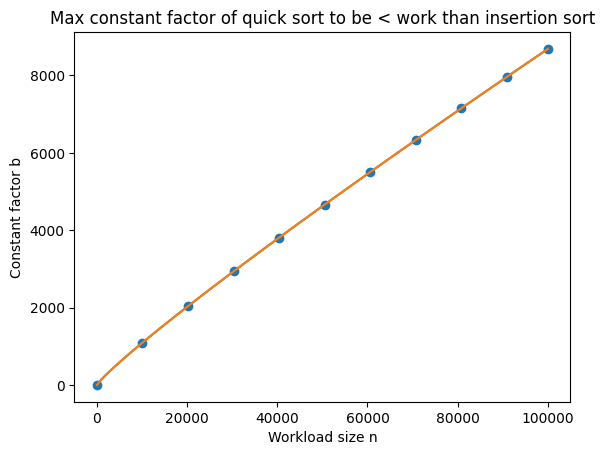

In [228]:
# Plot relationship between constant factor b and n
b = np.linspace(1, 10, 100)
n = np.linspace(2, 100000, 100)
b = n / np.log(n)

# Add markers to visualize various points along the curve
plt.plot(n, b, marker='o', markevery=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 99])
plt.plot(n, b)
plt.xlabel("Workload size n")
plt.ylabel("Constant factor b")
plt.title("Max constant factor of quick sort to be < work than insertion sort")
plt.show()

## 7.14

> Imagine that there exists an algorithm `SPLITk` that can split a list `L` of $n$
> elements into $k$ sublists, each containing one or more elements, such that
> sublist $i$ contains only elements whose values are less than all elements in
> sublist $j$ for $i < j <= k$. If $n < k$, then $k − n$ sublists are empty, and the rest
> are of length $1$. Assume that `SPLITk` has time complexity $O(\text{length of L})$.
> Furthermore, assume that the $k$ lists can be concatenated again in constant
> time. Consider the following algorithm:

### (a)

> What is the worst-case asymptotic running time for SORTk? Why?

---


The worst-case for `SORTk` can resemble the worst-case for `Quicksort` when $k = 1$ (whether by constraints of the problem or by nature of bad pivots/splitting implementation). I.e., we only separeted into one list with a single item and one other list with $n - 1$ items (just like partitioning into a list containing just the pivot and another list containing all the other items).

In this case, the time complexity is $O(n^2)$, since we only progress (in terms of sortedness) by one element at each step. I.e., sorting requires $n$ splits, each taking $O(n)$ time.




### (b) 

> What is the average-case asymptotic running time of SORTk? Why?

---

The average-case time complexity of `SORTk` is $O(n \log_k n)$ if $k > 2$ and $O(n^2)$ if $k < 3$.

Consider when $k = 2$:

- Step 1: split into $[e]$, $[n - 1]$
- Step 2: split into $[e_1, e_2]$, $[n - 2]$
- $\ldots$
- Requires $n$ splits and re-merges to sort fully

Consider when $k = 3$:

- Step 1: split into $[e]$, $[e]$, $[n - 2]$
- Step 2: split into $[e_1, e_2]$, $[e_1, e_2]$, $[n - 4]$
- Step 3: split into $[e_1, e_2, e_3, e_4]$, $[e_1, e_2, e_3, e_4]$, $[n - 8]$
- $\ldots$
- Requires $\log_2 n$ splits and re-merges to sort fully

This is the same as the time complexity for `mergesort` or `quicksort`, which makes sense.

Consider the general case for $k$:

- Step 1: split into $[e]$, $[e]$, $\ldots$, $[n - k]$
- Step 2: split into $[e_1, \ldots, e_k]$, $[e_1, \ldots, e_k]$, $\ldots$, $[n - k^2]$
- Step 3: split into $[e_1, \ldots, e_k, e_1, \ldots, e_k]$, $[e_1, \ldots, e_k, e_1, \ldots, e_k]$, $\ldots$, $[n - k^3]$
- $\ldots$
- Each sublist has approximately $\frac{n}{k}$ elements
- Requires $\log k$ splits and re-merges to sort fully


The algorithm will be complete when the last $[n - n]$ sublist is of length $0$. Thus, we are looking for the exponent $x$ such that:

$$
\text{Number of lists}^x = n \implies x = \log_k n
$$

Hence, our time complexity is $O(n \log_k n)$.

## 7.15

> Here is a variation on sorting. The problem is to sort a collection of n nuts
> and n bolts by size. It is assumed that for each bolt in the collection, there
> is a corresponding nut of the same size, but initially we do not know which
> nut goes with which bolt. The differences in size between two nuts or two
> bolts can be too small to see by eye, so you cannot rely on comparing the
> sizes of two nuts or two bolts directly. Instead, you can only compare the
> sizes of a nut and a bolt by attempting to screw one into the other (assume
> this comparison to be a constant time operation). This operation tells you
> that either the nut is bigger than the bolt, the bolt is bigger than the nut, or
> they are the same size. What is the minimum number of comparisons needed
> to sort the nuts and bolts in the worst case?

----

No matter how clever you are, the worst-case scenario will involve unbalanced partitions where you end up performing $n$ comparisons for each partition or level, leading to a total of $O(n^2)$ comparisons. This limitation arises because you can only compare a nut and a bolt at a time, and the partitioning process can result in unbalanced splits that require a large number of comparisons to sort.

This problem demonstrates that even when restricted to specific types of comparisons, divide-and-conquer strategies can still be applied effectively. However, the $O(n^2)$ worst-case complexity remains a natural limitation for this type of problem due to the constrained comparison model. The key takeaway is learning how to adapt familiar sorting algorithms to unusual constraints.

## 7.16

> [7.16a, 7.16b] (a) Devise an algorithm to sort three numbers. It should make as few comparisons as possible. How many comparisons and swaps are required in the best, worst, and average cases? 
> 
> (b) Devise an algorithm to sort five numbers. It should make as few comparisons as possible. How many comparisons and swaps are required in the best, worst, and average cases?

---

### Sorting Three Numbers

#### Algorithm

```java
void sortThree(int[] arr) {
  if (arr[0] > arr[1]) swap(arr, 0, 1);
  if (arr[1] > arr[2]) swap(arr, 1, 2);
  if (arr[0] > arr[1]) swap(arr, 0, 1);
}

void swap(int[] arr, int i, int j) {
  int temp = arr[i];
  arr[i] = arr[j];
  arr[j] = temp;
}
```

#### Analysis

- **Comparisons**:
  - The algorithm uses *exactly* $3$ comparisons in all cases, it does not vary with the input order.

- **Swaps**:
  - Best Case: $0$ swaps (when $arr[0] \leq arr[1] \leq arr[2]$)
  - Worst Case: $3$ swaps (when $arr[0] > arr[1] > arr[2]$)
  - Average Case: $\approx 1$ swap

### Sorting Five Numbers

#### Algorithm

```java
void sortFive(int[] arr) {
  for (int i = 0; i < 4; i++) {
    int minIndex = i;
    for (int j = i + 1; j < 5; j++) if (arr[j] < arr[minIndex]) minIndex = j;
    if (minIndex != i) swap(arr, i, minIndex);
  }
}

void swap(int[] arr, int i, int j) {
  int temp = arr[i];
  arr[i] = arr[j];
  arr[j] = temp;
}
```

#### Analysis

- **Comparisons**:
  - Consider each pass of the outer loop:
    - Pass 1: $4$ comparisons
    - Pass 2: $3$ comparisons
    - Pass 3: $2$ comparisons
    - Pass 4: $1$ comparison
  - In general, $\frac{n(n-1)}{2}$ comparisons for $n$ elements.
  - Best Case: $10$ comparisons
  - Worst Case: $10$ comparisons
  - Average Case: $10$ comparisons

- **Swaps**:
  - Best Case: $0$ swaps (when the array is already sorted)
  - Worst Case: $4$ swaps
    - For example

        Starting list: `[2, 4, 5, 3, 1]`

        After swap 1: `[1, 4, 5, 3, 2]`

        After swap 2: `[1, 2, 5, 3, 4]`

        After swap 3: `[1, 2, 3, 5, 4]`

        After swap 4: `[1, 2, 3, 4, 5]`
  - Average Case: $\approx 2$ swaps


## 7.17


> Devise an efficient algorithm to sort a set of numbers with values in the range
> $0$ to $30,000$. There are no duplicates. Keep memory requirements to a mini-
> mum.

----

Idea: use counting sort by creating keymappings to strings of bits that can represent $\geq 30,000$ values.

## 7.18


> Which of the following operations are best implemented by first sorting the
> list of numbers? For each operation, briefly describe an algorithm to imple-
> ment it, and state the algorithm’s asymptotic complexity.
>
> - Find the minimum value.
> - Find the maximum value.
> - Compute the arithmetic mean.
> - Find the median (i.e., the middle value).
> - Find the mode (i.e., the value that appears the most times).

----

### Find the Minimum/Maximum Value

The best performance using a sorting algorithm involves sorting the list using heapsort or quicksort and returning the first/last element.

Since this can be done in linear $O(n)$ time by simply iterating through the list, sorting is not the best approach for finding the minimum or maximum value.

### Compute the Arithmetic Mean

Nothing about finding the mean is improved by sorting the list. The mean can be computed in linear time by summing all elements and dividing by the number of elements.

### Find the Median

**Algorithm**: Sort the first $n/2$ elements of the list using a selection algorithm (e.g., quickselect) to find the median.

**Complexity**: $O(n)$

### Find the Mode

One of the faster approaches to finding the mode is to iterate through the list and keep track of counts using a hash table or array. The value with the highest count is the mode.

Since this approach is $O(n)$, sorting the list is not the best method for finding the mode.

### Summary

| **Operation**            | **Best Algorithm** | **Best Complexity** | **Is Sorting Best?** |
|---------------------------|--------------------|----------------------|-----------------------|
| Find Minimum Value        | Linear Scan       | O(n)                | No                   |
| Find Maximum Value        | Linear Scan       | O(n)                | No                   |
| Compute Arithmetic Mean   | Linear Scan       | O(n)                | No                   |
| Find Median               | Quickselect       | O(n) (avg)          | No                   |
| Find Mode                 | Hash Table        | O(n)                | No                   |


## 7.19

> Consider a recursive Mergesort implementation that calls Insertion Sort on
> sublists smaller than some threshold. If there are n calls to Mergesort, how
> many calls will there be to Insertion Sort? Why?

----

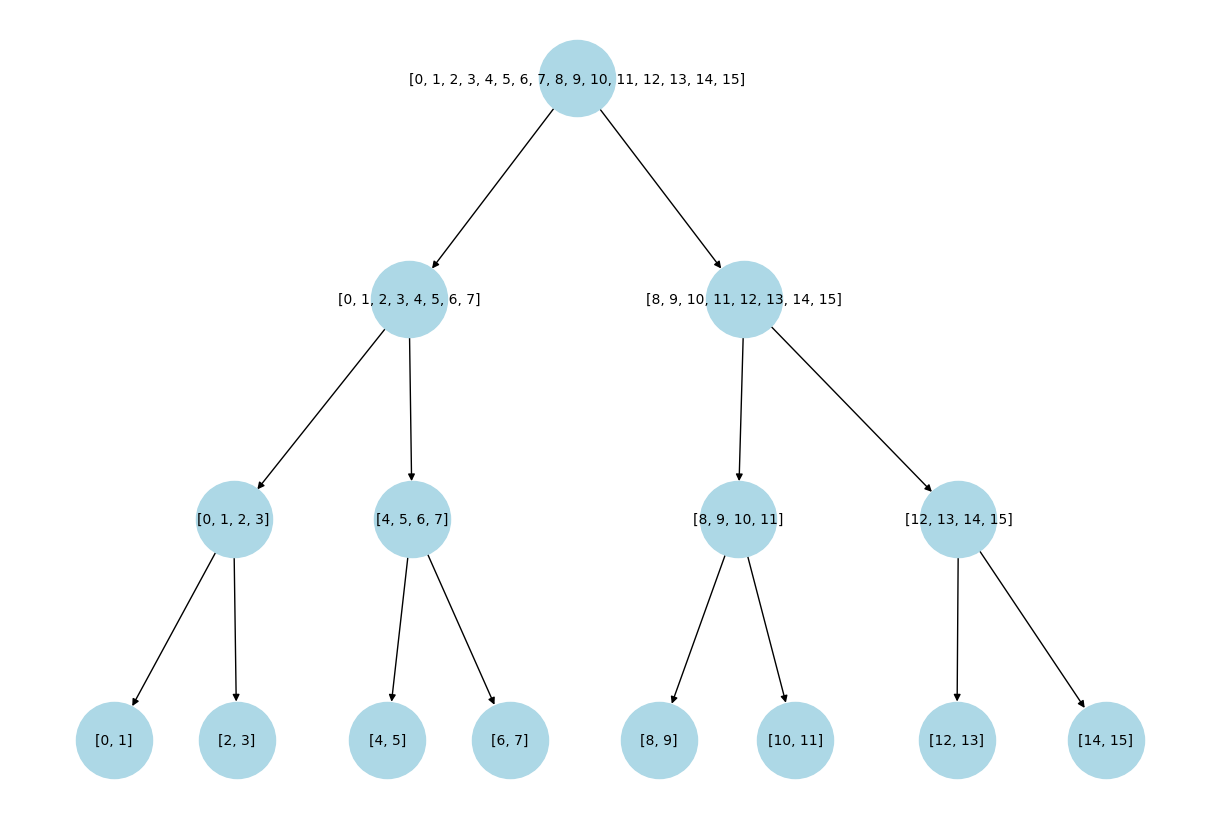

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

def build_merge_sort_tree(data, G, parent=None):
    """
    Recursively build a merge sort tree.
    - `data` is the current list being split.
    - `G` is the networkx graph.
    - `parent` is the parent node of the current subtree.
    """
    if len(data) <= 3:
        # Leaf node: when insertion sort is called
        leaf_label = f"{data}"
        G.add_node(leaf_label)
        if parent:
            G.add_edge(parent, leaf_label)
        return

    # Split the data
    mid = len(data) // 2
    left = data[:mid]
    right = data[mid:]

    # Create a node for the current list
    node_label = f"{data}"
    G.add_node(node_label)
    if parent:
        G.add_edge(parent, node_label)

    # Recursively add left and right children
    build_merge_sort_tree(left, G, node_label)
    build_merge_sort_tree(right, G, node_label)

def visualize_tree(G):
    """
    Visualize the tree using a hierarchical layout.
    """
    pos = nx.nx_agraph.graphviz_layout(G, prog="dot")  # Hierarchical layout
    plt.figure(figsize=(12, 8))
    nx.draw(G, pos, with_labels=True, node_size=3000, node_color="lightblue", font_size=10)
    plt.show()


#### List of 9 with Threshold of 3

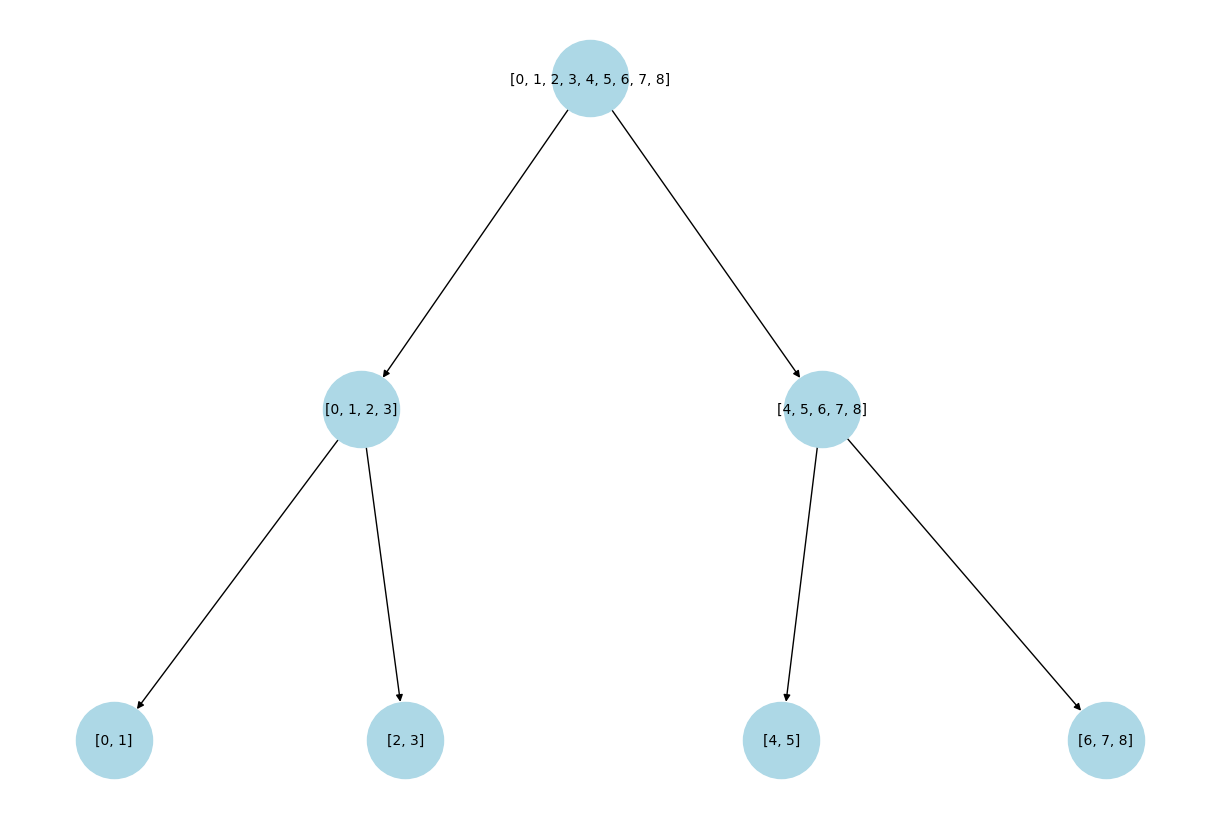

In [3]:
data = list(range(9))  # Example input list for merge sort
G = nx.DiGraph()  # Directed graph for hierarchical structure
build_merge_sort_tree(data, G)
visualize_tree(G)

#### List of 13 with Threshold of 3 (Next Jump)

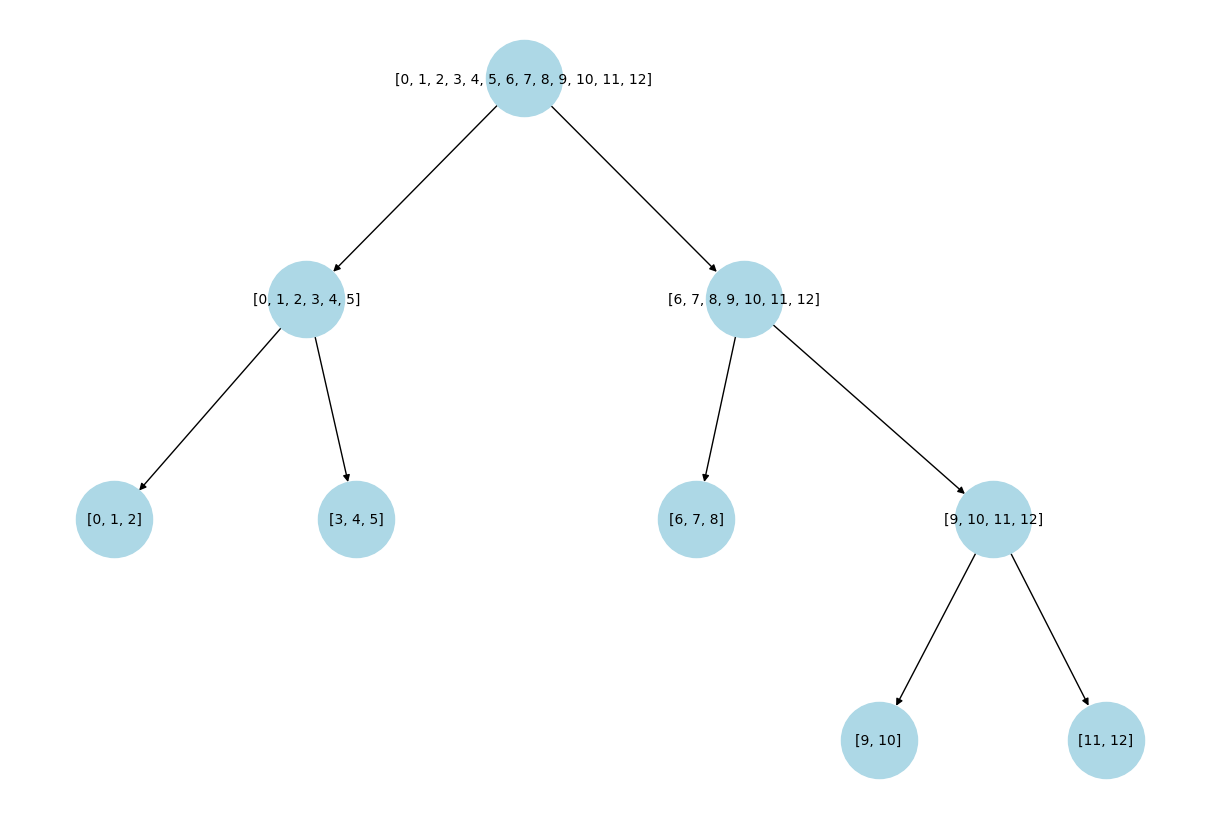

In [7]:
data = list(range(13))  # Example input list for merge sort
G = nx.DiGraph()  # Directed graph for hierarchical structure
build_merge_sort_tree(data, G)
visualize_tree(G)

### Correct Answer

The number of calls to Insertion Sort in a recursive Merge Sort with threshold $T$ is:

$$
\lceil n / T \rceil
$$

#### Key Examples:

1. If $n = 15$ and $T = 3$:
   - Tree depth: 
     $$
     d = \lceil \log_2(15 / 3) \rceil = \lceil \log_2(5) \rceil = 3
     $$
   - Number of sublists:
     $$
     \text{Number of leaves} = \lceil 15 / 3 \rceil = 5
     $$

2. If $n = 15$ and $T = 7$:
   - Tree depth:
     $$
     d = \lceil \log_2(15 / 7) \rceil = \lceil \log_2(2.14) \rceil = 2
     $$
   - Number of sublists:
     $$
     \text{Number of leaves} = \lceil 15 / 7 \rceil = 3
     $$

#### Insights:

1. The number of calls to Insertion Sort corresponds to the number of sublists of size $\leq T$, determined by recursive splitting.
2. The key formula for the number of Insertion Sort calls is:
   $$
   \lceil n / T \rceil
   $$
3. This formula reflects the total number of base-case sublists created during the recursion.



## 7.20

> Implement Mergesort for the case where the input is a linked list.

----

In [14]:
class Node:
    def __init__(self, data):
        self.data = data
        self.next = None

    def __str__(self):
        # Helper to print the entire linked list
        result = []
        cur = self
        while cur:
            result.append(str(cur.data))
            cur = cur.next
        return " -> ".join(result) + " -> None"


def merge_sort(head: Node) -> Node:
    # Base case: if the list is empty or has one node, it is sorted
    if not head or not head.next:
        return head

    # Step 1: Split the list into two halves
    middle = get_middle(head)
    right_half = middle.next
    middle.next = None  # Break the list into two halves

    # Step 2: Recursively sort the two halves
    left_sorted = merge_sort(head)
    right_sorted = merge_sort(right_half)

    # Step 3: Merge the two sorted halves
    return merge_sorted_lists(left_sorted, right_sorted)


def get_middle(head: Node) -> Node:
    # Use the slow and fast pointer technique to find the middle node
    slow = head
    fast = head

    while fast.next and fast.next.next:
        slow = slow.next
        fast = fast.next.next

    return slow


def merge_sorted_lists(left: Node, right: Node) -> Node:
    # Merge two sorted linked lists
    dummy = Node(0)  # Dummy node to simplify merging
    tail = dummy

    while left and right:
        if left.data <= right.data:
            tail.next = left
            left = left.next
        else:
            tail.next = right
            right = right.next
        tail = tail.next

    # Append any remaining nodes
    tail.next = left if left else right

    return dummy.next


import random
def construct_random_example_llist():
    head = Node(10)
    cur = head
    for i in range(9, 0, -1):
        random_value = random.randint(0, 100)
        cur.next = Node(random_value)
        cur = cur.next
    return head

llist = construct_random_example_llist()
print(f"Linked List before sorting: {llist}")
merged = merge_sort(llist)
print(f"Linked List after sorting: {merged}")

Linked List before sorting: 10 -> 27 -> 38 -> 29 -> 31 -> 0 -> 6 -> 58 -> 1 -> 1 -> None
Linked List after sorting: 0 -> 1 -> 1 -> 6 -> 10 -> 27 -> 29 -> 31 -> 38 -> 58 -> None


## 7.21


> Counting sort (assuming the input key values are integers in the range 0 to
> m − 1) works by counting the number of records with each key value in the
> first pass, and then uses this information to place the records in order in a
> second pass. Write an implementation of counting sort (see the implementa-
> tion of radix sort for some ideas). What can we say about the relative values
> of m and n for this to be effective? If m < n, what is the running time of
> this algorithm?

----

In [ ]:
def counting_sort(arr):
    # Step 1: Find the maximum element in the array
    max_element = max(arr)

    # Step 2: Create a frequency array to store the count of each unique element
    freq = [0] * (max_element + 1)
    for x in arr:
        freq[x] += 1

    # Step 3: Generate the sorted array
    sorted_arr = []
    for i, count in enumerate(freq):
        sorted_arr.extend([i] * count)

    return sorted_arr

For counting sort to be effective, $m$ should be significantly smaller than $n$ to avoid excessive memory usage and redundant counting operations. If $m < n$, the running time of counting sort is $O(n)$, as the counting and placement steps both require linear time complexity.

Additionally, the range of key values $m$ should be small enough to fit within the available memory for the counting array. If $m$ is too large, the memory requirements for the counting array may become prohibitive, making counting sort less practical.

## 7.22

> Use an argument similar to that given in Section 7.9 to prove that log n is a
> worst-case lower bound for the problem of searching for a given value in a
> sorted array containing n elements.

---

If the list is sorted, we can find any item in the list using binary search. 

A list of length $n$ can only be divided in half at most $\log_2 n$ times.

Thus, the worst-case lower bound for searching in a sorted list is $\log_2 n$.

## 7.23

> A simpler way to do the Quicksort partition step is to set index **split**
> to the position of the first value greater than the pivot. Then from posi-
> tion **split+1** have another index **curr** move to the right until it finds a
> value less than a pivot. Swap the values at **split** and **next**, and incre-
> ment **split**. Continue in this way, swapping the smaller values to the left
> side. When **curr** reaches the end of the subarray, **split** will be at the split
> point between the two partitions. Unfortunately, this approach requires more
> swaps than does the version presented in Section 7.5, resulting in a slower
> implementation. Give an example and explain why

----

In [ ]:
from rich.table import Table
from rich.console import Console

def visualize_pointers(arr, pivot, swap, curr, title=False):
    if title:
      table = Table(title=str(title))
    else:
      table = Table()
    for i, x in enumerate(arr):
        table.add_column(f"[{i}]", justify="center")
    table.add_row(*[str(x) for x in arr])
    table.add_row()
    cols = []
    pivot_printed = False
    for i in range(len(arr)):
        # if arr[i] == pivot:
        #     cols.append("Pivot")
        if i == swap and i == curr:
            cols.append("Split, Curr" + (", Pivot" if arr[i] == pivot else ""))
        elif i == swap:
            cols.append("Split" + (", Pivot" if arr[i] == pivot else ""))
        elif i == curr:
            cols.append("Curr" + (", Pivot" if arr[i] == pivot else ""))
        elif arr[i] == pivot and not pivot_printed:
            cols.append("Pivot")
            pivot_printed = True
        else:
            cols.append("")
    table.add_row(*cols)
    console = Console()
    console.print(table)


#### Standard Quicksort

In [73]:
partition_comparisons_q = 1
setup_comparisons_q = 1

def quick_sort(arr):
    global partition_comparisons_q
    global setup_comparisons_q

    def partition(arr, low, high):
        global partition_comparisons_q
        pivot = arr[(low + high) // 2]
        i = low - 1
        for j in range(low, high):
            partition_comparisons_q += 1
            if arr[j] < pivot:
                visualize_pointers(arr, pivot, low, high, title=f"Swapping {arr[j]} and {arr[i + 1]}")
                i += 1
                arr[i], arr[j] = arr[j], arr[i]
        arr[i + 1], arr[high] = arr[high], arr[i + 1]
        return i + 1

    def quick_sort_helper(arr, low, high):
        if low < high:
            pi = partition(arr, low, high)
            quick_sort_helper(arr, low, pi - 1)
            quick_sort_helper(arr, pi + 1, high)

    quick_sort_helper(arr, 0, len(arr) - 1)
    print(f"Total comparisons for partitioning: {partition_comparisons_q + setup_comparisons_q}")

arr = [5, 3, 4, 6, 8, 9, 2, 1, 0, 7]
print(f"Original array: {arr}")
quick_sort(arr)


Original array: [5, 3, 4, 6, 8, 9, 2, 1, 0, 7]


                         Swapping 5 and 5                         
┏━━━━━━━┳━━━━━┳━━━━━┳━━━━━┳━━━━━━━┳━━━━━┳━━━━━┳━━━━━┳━━━━━┳━━━━━━┓
┃  [0]  ┃ [1] ┃ [2] ┃ [3] ┃  [4]  ┃ [5] ┃ [6] ┃ [7] ┃ [8] ┃ [9]  ┃
┡━━━━━━━╇━━━━━╇━━━━━╇━━━━━╇━━━━━━━╇━━━━━╇━━━━━╇━━━━━╇━━━━━╇━━━━━━┩
│   5   │  3  │  4  │  6  │   8   │  9  │  2  │  1  │  0  │  7   │
│       │     │     │     │       │     │     │     │     │      │
│ Split │     │     │     │ Pivot │     │     │     │     │ Curr │
└───────┴─────┴─────┴─────┴───────┴─────┴─────┴─────┴─────┴──────┘

                         Swapping 3 and 3                         
┏━━━━━━━┳━━━━━┳━━━━━┳━━━━━┳━━━━━━━┳━━━━━┳━━━━━┳━━━━━┳━━━━━┳━━━━━━┓
┃  [0]  ┃ [1] ┃ [2] ┃ [3] ┃  [4]  ┃ [5] ┃ [6] ┃ [7] ┃ [8] ┃ [9]  ┃
┡━━━━━━━╇━━━━━╇━━━━━╇━━━━━╇━━━━━━━╇━━━━━╇━━━━━╇━━━━━╇━━━━━╇━━━━━━┩
│   5   │  3  │  4  │  6  │   8   │  9  │  2  │  1  │  0  │  7   │
│       │     │     │     │       │     │     │     │     │      │
│ Split │     │     │     │ Pivot │     │     │     │     │ Curr │
└───────┴─────┴─────┴─────┴───────┴─────┴─────┴─────┴─────┴──────┘

                         Swapping 4 and 4                         
┏━━━━━━━┳━━━━━┳━━━━━┳━━━━━┳━━━━━━━┳━━━━━┳━━━━━┳━━━━━┳━━━━━┳━━━━━━┓
┃  [0]  ┃ [1] ┃ [2] ┃ [3] ┃  [4]  ┃ [5] ┃ [6] ┃ [7] ┃ [8] ┃ [9]  ┃
┡━━━━━━━╇━━━━━╇━━━━━╇━━━━━╇━━━━━━━╇━━━━━╇━━━━━╇━━━━━╇━━━━━╇━━━━━━┩
│   5   │  3  │  4  │  6  │   8   │  9  │  2  │  1  │  0  │  7   │
│       │     │     │     │       │     │     │     │     │      │
│ Split │     │     │     │ Pivot │     │     │     │     │ Curr │
└───────┴─────┴─────┴─────┴───────┴─────┴─────┴─────┴─────┴──────┘

                         Swapping 6 and 6                         
┏━━━━━━━┳━━━━━┳━━━━━┳━━━━━┳━━━━━━━┳━━━━━┳━━━━━┳━━━━━┳━━━━━┳━━━━━━┓
┃  [0]  ┃ [1] ┃ [2] ┃ [3] ┃  [4]  ┃ [5] ┃ [6] ┃ [7] ┃ [8] ┃ [9]  ┃
┡━━━━━━━╇━━━━━╇━━━━━╇━━━━━╇━━━━━━━╇━━━━━╇━━━━━╇━━━━━╇━━━━━╇━━━━━━┩
│   5   │  3  │  4  │  6  │   8   │  9  │  2  │  1  │  0  │  7   │
│       │     │     │     │       │     │     │     │     │      │
│ Split │     │     │     │ Pivot │     │     │     │     │ Curr │
└───────┴─────┴─────┴─────┴───────┴─────┴─────┴─────┴─────┴──────┘

...

                         Swapping 2 and 6                         
┏━━━━━━━┳━━━━━┳━━━━━┳━━━━━━━┳━━━━━┳━━━━━┳━━━━━━┳━━━━━┳━━━━━┳━━━━━┓
┃  [0]  ┃ [1] ┃ [2] ┃  [3]  ┃ [4] ┃ [5] ┃ [6]  ┃ [7] ┃ [8] ┃ [9] ┃
┡━━━━━━━╇━━━━━╇━━━━━╇━━━━━━━╇━━━━━╇━━━━━╇━━━━━━╇━━━━━╇━━━━━╇━━━━━┩
│   5   │  3  │  4  │   6   │  2  │  1  │  0   │  7  │  8  │  9  │
│       │     │     │       │     │     │      │     │     │     │
│ Split │     │     │ Pivot │     │     │ Curr │     │     │     │
└───────┴─────┴─────┴───────┴─────┴─────┴──────┴─────┴─────┴─────┘

                         Swapping 1 and 6                         
┏━━━━━━━┳━━━━━┳━━━━━┳━━━━━┳━━━━━━━┳━━━━━┳━━━━━━┳━━━━━┳━━━━━┳━━━━━┓
┃  [0]  ┃ [1] ┃ [2] ┃ [3] ┃  [4]  ┃ [5] ┃ [6]  ┃ [7] ┃ [8] ┃ [9] ┃
┡━━━━━━━╇━━━━━╇━━━━━╇━━━━━╇━━━━━━━╇━━━━━╇━━━━━━╇━━━━━╇━━━━━╇━━━━━┩
│   5   │  3  │  4  │  2  │   6   │  1  │  0   │  7  │  8  │  9  │
│       │     │     │     │       │     │      │     │     │     │
│ Split │     │     │     │ Pivot │     │ Curr │     │     │     │
└───────┴─────┴─────┴─────┴───────┴─────┴──────┴─────┴─────┴─────┘

                         Swapping 3 and 5                         
┏━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━┳━━━━━━┳━━━━━┳━━━━━┳━━━━━┳━━━━━┳━━━━━┓
┃  [0]  ┃ [1] ┃  [2]  ┃ [3] ┃ [4]  ┃ [5] ┃ [6] ┃ [7] ┃ [8] ┃ [9] ┃
┡━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━╇━━━━━━╇━━━━━╇━━━━━╇━━━━━╇━━━━━╇━━━━━┩
│   5   │  3  │   4   │  2  │  1   │  0  │  6  │  7  │  8  │  9  │
│       │     │       │     │      │     │     │     │     │     │
│ Split │     │ Pivot │     │ Curr │     │     │     │     │     │
└───────┴─────┴───────┴─────┴──────┴─────┴─────┴─────┴─────┴─────┘

                         Swapping 2 and 5                         
┏━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━┳━━━━━━┳━━━━━┳━━━━━┳━━━━━┳━━━━━┳━━━━━┓
┃  [0]  ┃ [1] ┃  [2]  ┃ [3] ┃ [4]  ┃ [5] ┃ [6] ┃ [7] ┃ [8] ┃ [9] ┃
┡━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━╇━━━━━━╇━━━━━╇━━━━━╇━━━━━╇━━━━━╇━━━━━┩
│   3   │  5  │   4   │  2  │  1   │  0  │  6  │  7  │  8  │  9  │
│       │     │       │     │      │     │     │     │     │     │
│ Split │     │ Pivot │     │ Curr │     │     │     │     │     │
└───────┴─────┴───────┴─────┴──────┴─────┴─────┴─────┴─────┴─────┘

Total comparisons for partitioning: 24


#### Split Quicksort

In [71]:
partition_comparisons = 2
setup_comparisons = 1

def partition_swap(arr, low, high):
    global partition_comparisons
    global setup_comparisons

    pivot = arr[low]
    print(f"Pivot is {pivot}")

    split = arr.index(max(arr[low:high + 1]))

    split = 0
    while arr[split] <= pivot and split < high + 1:
      setup_comparisons += 1
      split += 1

    # TODO: handle when this goes out of bounds
    curr = split + 1
    visualize_pointers(arr, pivot, split, curr, title="Initial State")

    while curr < high:
      partition_comparisons += 1
      while arr[curr] >= pivot and curr < high:
        partition_comparisons += 1
        curr += 1
      if curr < high:
        visualize_pointers(arr, pivot, split, curr, title=f"Found value < pivot: {arr[curr]}")
        arr[split], arr[curr] = arr[curr], arr[split]
        visualize_pointers(arr, pivot, split, curr, title=f"Swapped {arr[curr]} with {arr[split]}")
        split += 1
        visualize_pointers(arr, pivot, split, curr, title="Split Incremented Right")

    print(f"\nArray after partitioning: {arr[:split]} | [{arr[split]}] | {arr[split + 1:]}")
    print(f"Total comparisons: {partition_comparisons + setup_comparisons} | Partition {partition_comparisons} + Setup {setup_comparisons}")


arr = [5, 3, 4, 6, 8, 9, 2, 1, 0, 7]
print(f"Original array: {arr}")
partition_swap(arr, 0, len(arr) - 1)

Original array: [5, 3, 4, 6, 8, 9, 2, 1, 0, 7]
Pivot is 5


                          Initial State                           
┏━━━━━━━┳━━━━━┳━━━━━┳━━━━━━━┳━━━━━━┳━━━━━┳━━━━━┳━━━━━┳━━━━━┳━━━━━┓
┃  [0]  ┃ [1] ┃ [2] ┃  [3]  ┃ [4]  ┃ [5] ┃ [6] ┃ [7] ┃ [8] ┃ [9] ┃
┡━━━━━━━╇━━━━━╇━━━━━╇━━━━━━━╇━━━━━━╇━━━━━╇━━━━━╇━━━━━╇━━━━━╇━━━━━┩
│   5   │  3  │  4  │   6   │  8   │  9  │  2  │  1  │  0  │  7  │
│       │     │     │       │      │     │     │     │     │     │
│ Pivot │     │     │ Split │ Curr │     │     │     │     │     │
└───────┴─────┴─────┴───────┴──────┴─────┴─────┴─────┴─────┴─────┘

                      Found value < pivot: 2                      
┏━━━━━━━┳━━━━━┳━━━━━┳━━━━━━━┳━━━━━┳━━━━━┳━━━━━━┳━━━━━┳━━━━━┳━━━━━┓
┃  [0]  ┃ [1] ┃ [2] ┃  [3]  ┃ [4] ┃ [5] ┃ [6]  ┃ [7] ┃ [8] ┃ [9] ┃
┡━━━━━━━╇━━━━━╇━━━━━╇━━━━━━━╇━━━━━╇━━━━━╇━━━━━━╇━━━━━╇━━━━━╇━━━━━┩
│   5   │  3  │  4  │   6   │  8  │  9  │  2   │  1  │  0  │  7  │
│       │     │     │       │     │     │      │     │     │     │
│ Pivot │     │     │ Split │     │     │ Curr │     │     │     │
└───────┴─────┴─────┴───────┴─────┴─────┴──────┴─────┴─────┴─────┘

                         Swapped 6 with 2                         
┏━━━━━━━┳━━━━━┳━━━━━┳━━━━━━━┳━━━━━┳━━━━━┳━━━━━━┳━━━━━┳━━━━━┳━━━━━┓
┃  [0]  ┃ [1] ┃ [2] ┃  [3]  ┃ [4] ┃ [5] ┃ [6]  ┃ [7] ┃ [8] ┃ [9] ┃
┡━━━━━━━╇━━━━━╇━━━━━╇━━━━━━━╇━━━━━╇━━━━━╇━━━━━━╇━━━━━╇━━━━━╇━━━━━┩
│   5   │  3  │  4  │   2   │  8  │  9  │  6   │  1  │  0  │  7  │
│       │     │     │       │     │     │      │     │     │     │
│ Pivot │     │     │ Split │     │     │ Curr │     │     │     │
└───────┴─────┴─────┴───────┴─────┴─────┴──────┴─────┴─────┴─────┘

                     Split Incremented Right                      
┏━━━━━━━┳━━━━━┳━━━━━┳━━━━━┳━━━━━━━┳━━━━━┳━━━━━━┳━━━━━┳━━━━━┳━━━━━┓
┃  [0]  ┃ [1] ┃ [2] ┃ [3] ┃  [4]  ┃ [5] ┃ [6]  ┃ [7] ┃ [8] ┃ [9] ┃
┡━━━━━━━╇━━━━━╇━━━━━╇━━━━━╇━━━━━━━╇━━━━━╇━━━━━━╇━━━━━╇━━━━━╇━━━━━┩
│   5   │  3  │  4  │  2  │   8   │  9  │  6   │  1  │  0  │  7  │
│       │     │     │     │       │     │      │     │     │     │
│ Pivot │     │     │     │ Split │     │ Curr │     │     │     │
└───────┴─────┴─────┴─────┴───────┴─────┴──────┴─────┴─────┴─────┘

...

                     Split Incremented Right                      
┏━━━━━━━┳━━━━━┳━━━━━┳━━━━━┳━━━━━┳━━━━━━━┳━━━━━┳━━━━━━┳━━━━━┳━━━━━┓
┃  [0]  ┃ [1] ┃ [2] ┃ [3] ┃ [4] ┃  [5]  ┃ [6] ┃ [7]  ┃ [8] ┃ [9] ┃
┡━━━━━━━╇━━━━━╇━━━━━╇━━━━━╇━━━━━╇━━━━━━━╇━━━━━╇━━━━━━╇━━━━━╇━━━━━┩
│   5   │  3  │  4  │  2  │  1  │   9   │  6  │  8   │  0  │  7  │
│       │     │     │     │     │       │     │      │     │     │
│ Pivot │     │     │     │     │ Split │     │ Curr │     │     │
└───────┴─────┴─────┴─────┴─────┴───────┴─────┴──────┴─────┴─────┘

                      Found value < pivot: 0                      
┏━━━━━━━┳━━━━━┳━━━━━┳━━━━━┳━━━━━┳━━━━━━━┳━━━━━┳━━━━━┳━━━━━━┳━━━━━┓
┃  [0]  ┃ [1] ┃ [2] ┃ [3] ┃ [4] ┃  [5]  ┃ [6] ┃ [7] ┃ [8]  ┃ [9] ┃
┡━━━━━━━╇━━━━━╇━━━━━╇━━━━━╇━━━━━╇━━━━━━━╇━━━━━╇━━━━━╇━━━━━━╇━━━━━┩
│   5   │  3  │  4  │  2  │  1  │   9   │  6  │  8  │  0   │  7  │
│       │     │     │     │     │       │     │     │      │     │
│ Pivot │     │     │     │     │ Split │     │     │ Curr │     │
└───────┴─────┴─────┴─────┴─────┴───────┴─────┴─────┴──────┴─────┘

                         Swapped 9 with 0                         
┏━━━━━━━┳━━━━━┳━━━━━┳━━━━━┳━━━━━┳━━━━━━━┳━━━━━┳━━━━━┳━━━━━━┳━━━━━┓
┃  [0]  ┃ [1] ┃ [2] ┃ [3] ┃ [4] ┃  [5]  ┃ [6] ┃ [7] ┃ [8]  ┃ [9] ┃
┡━━━━━━━╇━━━━━╇━━━━━╇━━━━━╇━━━━━╇━━━━━━━╇━━━━━╇━━━━━╇━━━━━━╇━━━━━┩
│   5   │  3  │  4  │  2  │  1  │   0   │  6  │  8  │  9   │  7  │
│       │     │     │     │     │       │     │     │      │     │
│ Pivot │     │     │     │     │ Split │     │     │ Curr │     │
└───────┴─────┴─────┴─────┴─────┴───────┴─────┴─────┴──────┴─────┘

                     Split Incremented Right                      
┏━━━━━━━┳━━━━━┳━━━━━┳━━━━━┳━━━━━┳━━━━━┳━━━━━━━┳━━━━━┳━━━━━━┳━━━━━┓
┃  [0]  ┃ [1] ┃ [2] ┃ [3] ┃ [4] ┃ [5] ┃  [6]  ┃ [7] ┃ [8]  ┃ [9] ┃
┡━━━━━━━╇━━━━━╇━━━━━╇━━━━━╇━━━━━╇━━━━━╇━━━━━━━╇━━━━━╇━━━━━━╇━━━━━┩
│   5   │  3  │  4  │  2  │  1  │  0  │   6   │  8  │  9   │  7  │
│       │     │     │     │     │     │       │     │      │     │
│ Pivot │     │     │     │     │     │ Split │     │ Curr │     │
└───────┴─────┴─────┴─────┴─────┴─────┴───────┴─────┴──────┴─────┘


Array after partitioning: [5, 3, 4, 2, 1, 0] | [6] | [8, 9, 7]
Total comparisons: 15 | Partition 11 + Setup 4
